# MMN 표준화

: 데이터를 정규화 할 때 사용하는 기법 중 하나로, 데이터의 평균과 최솟값을 기준으로 값 변환


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import pearsonr, spearmanr, kendalltau
import matplotlib.font_manager as fm

fm.fontManager.ttflist

# 나눔글꼴 경로 설정
font_path = '/Users/jin/AppData/Local/Microsoft/Windows/Fonts/NanumSquareOTF_0.otf'

# 폰트 이름 가져오기
font_name = fm.FontProperties(fname=font_path).get_name()

# 폰트 설정
plt.rc('font', family=font_name)
plt.rcParams['axes.unicode_minus']=False


# --------------------------------------------------
# 1) 데이터 로드
# --------------------------------------------------
df = pd.read_csv("~\side\O2O\data\MMN_raw.csv")

# --------------------------------------------------
# 2) MMN 함수 (R과 동일 방식)
# --------------------------------------------------
def MMN(x):
    return np.round((x - np.nanmin(x)) / (np.nanmean(x) - np.nanmin(x)), 3)

# --------------------------------------------------
# 3) 시간대 추출 + 가중치
# --------------------------------------------------
df["hour"] = df["min_part2"].str[:2].astype(int)

df["correction_weight"] = np.where(
    df["hour"].isin(list(range(6,10)) + list(range(24,28))),
    3.0,
    0
)

# --------------------------------------------------
# 4) 보정 지표 생성
# --------------------------------------------------
df["modified_call_ov_LV"] = np.where(
    (df["recom_successed_rate"].isna()) |
    (df["recom_successed_rate"] == 0),
    np.nan,
    (1 / (df["recom_successed_rate"] / 100)) *
    df["correction_weight"] +
    df["call_ov_LV"]
)

# --------------------------------------------------
# 5) MMN 정규화
# --------------------------------------------------
df["mmn_call_ov_LV"] = MMN(df["call_ov_LV"])
df["mmn_modified_call_ov_LV"] = MMN(df["modified_call_ov_LV"])

# --------------------------------------------------
# 6) 상관계수 계산
# --------------------------------------------------
x1 = df["mmn_call_ov_LV"]
x2 = df["mmn_modified_call_ov_LV"]
y  = df["reg_rec_diff"]

print("Pearson 기존:", round(pearsonr(x1.dropna(), y.loc[x1.notna()])[0],3))
print("Pearson 보정:", round(pearsonr(x2.dropna(), y.loc[x2.notna()])[0],3))

print("\n Spearman 기존:", round(spearmanr(x1, y, nan_policy='omit')[0],3))
print("Spearman 보정:", round(spearmanr(x2, y, nan_policy='omit')[0],3))

print("\n Kendall 기존:", round(kendalltau(x1, y, nan_policy='omit')[0],3))
print("Kendall 보정:", round(kendalltau(x2, y, nan_policy='omit')[0],3))


Pearson 기존: 0.215
Pearson 보정: 0.599

 Spearman 기존: 0.603
Spearman 보정: 0.761

 Kendall 기존: 0.477
Kendall 보정: 0.624


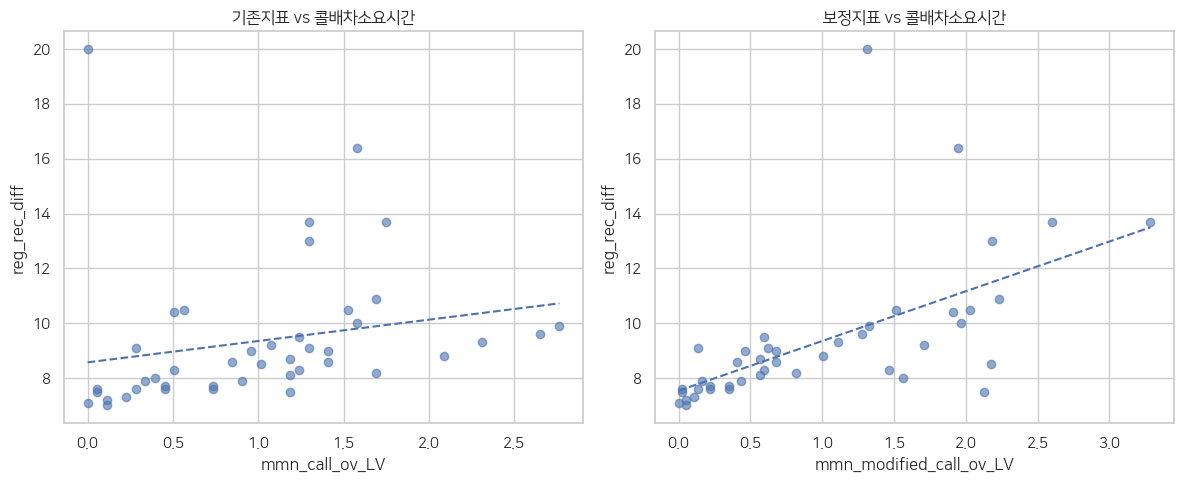

In [3]:
# --------------------------------------------------
# 7) 시각화 (2개 비교)
# --------------------------------------------------
%matplotlib inline
def add_trendline(ax, x, y):
    # 결측 제거
    mask = (~np.isnan(x)) & (~np.isnan(y))
    x_ = x[mask]
    y_ = y[mask]
    if len(x_) < 2:
        return

    # 1차 회귀선 y = a*x + b
    a, b = np.polyfit(x_, y_, 1)
    xs = np.linspace(x_.min(), x_.max(), 100)
    ax.plot(xs, a*xs + b, linestyle="--")  # 추세선

# y는 reg_rec_diff
y = df["reg_rec_diff"].to_numpy(dtype=float)

x1 = df["mmn_call_ov_LV"].to_numpy(dtype=float)
x2 = df["mmn_modified_call_ov_LV"].to_numpy(dtype=float)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# 기존지표
axes[0].scatter(x1, y, alpha=0.6)
add_trendline(axes[0], x1, y)
axes[0].set_title("기존지표 vs 콜배차소요시간")
axes[0].set_xlabel("mmn_call_ov_LV")
axes[0].set_ylabel("reg_rec_diff")

# 보정지표
axes[1].scatter(x2, y, alpha=0.6)
add_trendline(axes[1], x2, y)
axes[1].set_title("보정지표 vs 콜배차소요시간")
axes[1].set_xlabel("mmn_modified_call_ov_LV")
axes[1].set_ylabel("reg_rec_diff")

plt.tight_layout()
plt.show()